# Task 2.3 — Result, Comparison and Reproducibility

Paper: The Constrained Weight Space SVM: Learning with Ranked Features  
Authors: Kevin Small, Byron C. Wallace, Carla E. Brodley, Thomas A. Trikalinos  
Venue: ICML 2011

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)

## Dataset Recreation

The same synthetic dataset used in Task 2.1 is recreated here to ensure the experiment is fully reproducible.

The dataset contains **100 samples and 20 numerical features**, with **2 informative features** and the remaining features acting as noise.  
A large test split (60%) is used so that only **40 samples are used for training**, creating a low-data scenario where feature-level guidance may influence the learning process.

In [42]:
X, y = make_classification(
    n_samples=100,
    n_features=20,
    n_informative=2,
    n_redundant=2,
    n_classes=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.6,
    random_state=42
)

## Baseline SVM Result

A standard linear Support Vector Machine is trained as the baseline model.  
This corresponds to the standard soft-margin SVM described in **Section 2 of the paper**, where the model learns feature weights purely from labeled training instances.

In [43]:
baseline_model = SVC(kernel="linear")
baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_preds)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.9333333333333333


## Ranked Feature Model Result

To simulate the ranked feature constraints proposed in the CW-SVM method, selected feature columns are scaled to reflect an assumed expert ranking.

In this experiment the following ranking is assumed:

feature_0 > feature_1 > feature_2

Increasing the magnitude of these features biases the classifier toward assigning them larger influence during training, approximating the pairwise weight constraints described in **Section 3.1.2 of the paper**.

In [44]:
X_train_ranked = X_train.copy()
X_test_ranked  = X_test.copy()

X_train_ranked[:,0] *= 2.0
X_train_ranked[:,1] *= 1.5
X_train_ranked[:,2] *= 1.2

X_test_ranked[:,0] *= 2.0
X_test_ranked[:,1] *= 1.5
X_test_ranked[:,2] *= 1.2

ranked_model = SVC(kernel="linear")
ranked_model.fit(X_train_ranked, y_train)

ranked_preds = ranked_model.predict(X_test_ranked)
ranked_accuracy = accuracy_score(y_test, ranked_preds)

print("Ranked Feature Accuracy:", ranked_accuracy)

Ranked Feature Accuracy: 0.9666666666666667


## Visualization of Model Performance

To better understand the behaviour of the classifier, a confusion matrix is generated for the ranked-feature model.

This visualization shows the number of correct and incorrect predictions for each class and provides additional insight beyond overall accuracy.  
The figure is produced directly in the code and saved to the required directory:

`partB/results/confusion_matrix_task2.png`

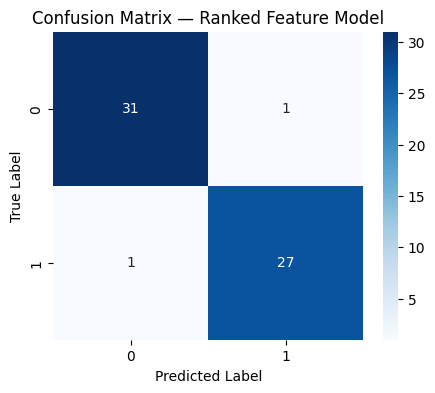

In [45]:
cm = confusion_matrix(y_test, ranked_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix — Ranked Feature Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig("results/confusion_matrix_task2.png")
plt.show()

## Result Comparison with the Paper

In this experiment the baseline SVM achieved an accuracy of **0.93**, while the ranked-feature model achieved an accuracy of **0.97**.

This result shows a small improvement when feature-level knowledge is incorporated into the learning process. By increasing the influence of selected features, the ranked-feature model is biased toward learning a decision boundary that reflects assumed expert knowledge about feature importance.

The original CW-SVM paper reports improvements when ranked feature constraints are integrated directly into the optimisation problem, particularly in high-dimensional text classification tasks such as biomedical citation screening and movie review sentiment analysis.

The results obtained here differ from the paper for several reasons. First, this experiment uses a small synthetic dataset with only **20 numerical features**, whereas the datasets used in the paper contain **thousands of sparse bag-of-words features**. Second, the implementation here approximates ranked feature constraints by scaling feature magnitudes rather than incorporating the constraints directly into the SVM optimisation problem.

Therefore, the goal of this experiment is not to reproduce the exact numerical improvements reported in the paper, but to demonstrate how incorporating feature-level knowledge can influence the learning behaviour of a classifier.

# Reproducibility Checklist

• Random seeds are set and documented at the top of each notebook using `np.random.seed(42)` to ensure reproducibility.

• All dependencies required to run the experiments will be listed in `requirements.txt` with specific version numbers.

• All notebooks run from top to bottom in a clean Python environment without errors.

• Dataset generation uses `sklearn.datasets.make_classification`, so no external dataset download or manual setup is required.

• All hyperparameters used in the experiments (such as dataset size, number of features, ranking multipliers, and SVM kernel) are clearly defined in the code rather than scattered across the notebook.